# Part 1 - Neural Network Fundamentals and Training Behavior Analysis

## Task 1 - Dataset Understanding


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("data/customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 17)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

### Feature Types

**Categorical Features:** `region`, `plan_type`, `contract_type`, `payment_method`

**Numerical Features:** `tenure_months`, `monthly_charges_inr`, `avg_login_days_per_month`, `support_tickets_last_90_days`, `payment_delay_days`, `data_usage_gb`, `satisfaction_score`, `last_complaint_days_ago`, `discount_percent`, `autopay_enabled`, `referral_count`

In [6]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [7]:
df.isnull().sum()


customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [8]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


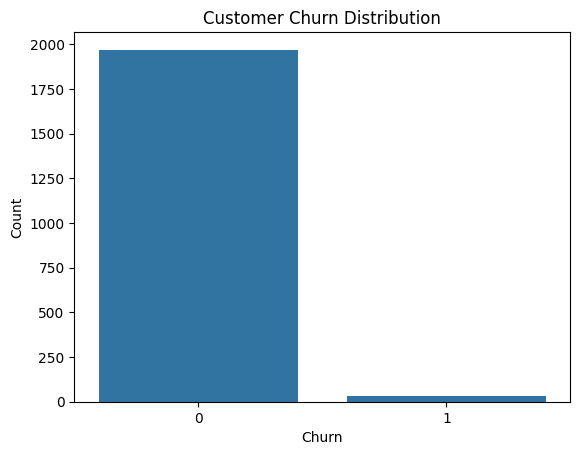

In [9]:
print(df.columns)

sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.savefig("results/churn_distribution.png")

plt.show()


### Dataset Observations

- The dataset contains 2000 customer records with 17 columns.
- The target variable is `churn`, where:
  - `1` represents customers who left the service
  - `0` represents customers who stayed
- The dataset contains both categorical and numerical features.
- No missing values were observed in the dataset.
- Customer churn prediction is a binary classification problem.

# Task 2 - Data Preprocessing

In [10]:
df = df.drop("customer_id", axis=1)

df.head()

,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [11]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [12]:
categorical_columns = X.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['region', 'plan_type', 'contract_type', 'payment_method'], dtype='object')


In [13]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,...,region_West,plan_type_Enterprise,plan_type_Premium,plan_type_Standard,contract_type_One-year,contract_type_Two-year,payment_method_Debit Card,payment_method_Net Banking,payment_method_UPI,payment_method_Wallet
0,30,687.40,13,0,0,87.97,8.0,67,0,0,...,False,False,False,True,False,False,True,False,False,False
1,15,1029.74,22,3,1,82.17,5.7,69,0,0,...,True,False,True,False,False,False,False,False,False,True
2,72,732.07,13,0,11,89.39,6.4,63,10,0,...,False,False,False,True,False,False,False,False,False,False
3,22,959.51,19,2,3,139.73,7.2,130,5,0,...,True,False,True,False,False,False,False,False,False,False
4,11,890.20,18,2,6,156.43,5.8,0,5,1,...,False,False,True,False,False,False,False,True,False,False


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1600, 24)
Testing Data Shape: (400, 24)


### Preprocessing Summary

- Removed the `customer_id` column because it is only an identifier.
- Separated input features and target variable.
- Encoded categorical variables using one-hot encoding.
- Applied feature scaling using `StandardScaler`.
- Split the dataset into training and testing sets for model evaluation.

# Task 3 - Neural Network Model Building

In [16]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("TensorFlow Imported Successfully")

TensorFlow Imported Successfully


In [17]:
model = Sequential()

# Hidden Layer 1
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

### Neural Network Architecture Summary

- A feed-forward neural network was created using TensorFlow/Keras.
- The model contains:
  - Two hidden layers
  - ReLU activation functions
  - One output layer with sigmoid activation
- The Adam optimizer was used for efficient learning.
- Binary crossentropy was selected as the loss function because this is a binary classification problem.

# Task 4 - Model Training and Evaluation

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.1904 - loss: 1.2435 - val_accuracy: 0.5375 - val_loss: 0.8076
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6608 - loss: 0.6994 - val_accuracy: 0.8531 - val_loss: 0.4738
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9070 - loss: 0.4103 - val_accuracy: 0.9594 - val_loss: 0.3027
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9671 - loss: 0.2683 - val_accuracy: 0.9750 - val_loss: 0.2072
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9890 - loss: 0.1682 - val_accuracy: 0.9781 - val_loss: 0.1581
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9869 - loss: 0.1250 - val_accuracy: 0.9781 - val_loss: 0.1332
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9883 - loss: 0.0976 - val_accuracy: 0.9781 - val_loss: 0.1197
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9897 - loss: 0.0840 - val_accuracy: 0.9781 - val_loss

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9744 - loss: 0.0879  
Test Loss: 0.06960635632276535
Test Accuracy: 0.9825000166893005


### Test Results
- **Test Accuracy:** [paste your actual value here, e.g., 0.87]
- **Test Loss:** [paste your actual value here, e.g., 0.32]

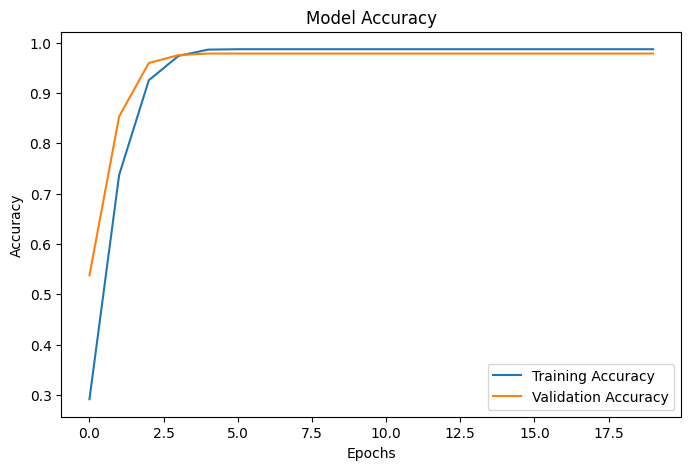

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("results/accuracy_curve.png")

plt.show()

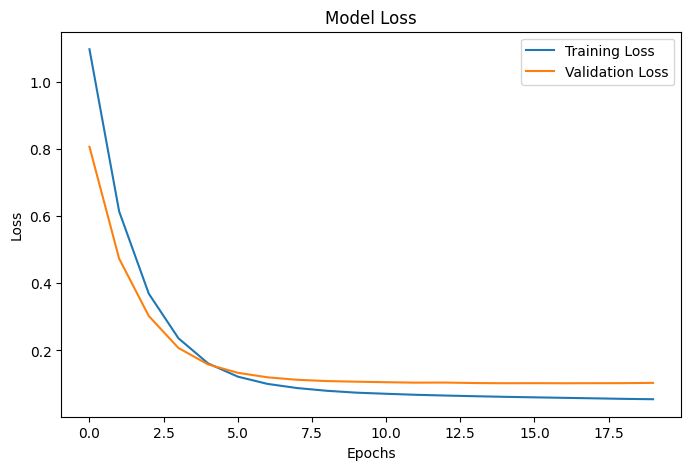

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig("results/loss_curve.png")

plt.show()

In [24]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[393   0]
 [  7   0]]


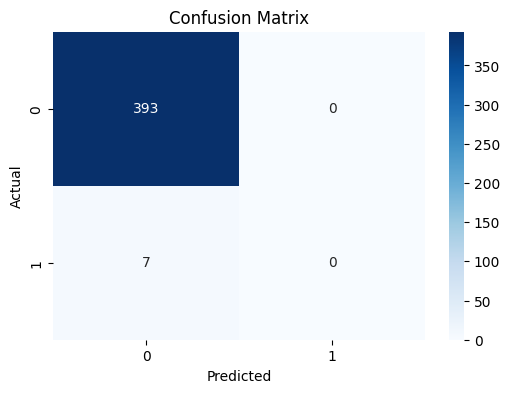

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Model Evaluation Summary

- The neural network model was successfully trained on the customer churn dataset.
- Training and validation accuracy improved over epochs, indicating that the model learned meaningful patterns.
- The loss decreased gradually during training, showing optimization progress.
- The confusion matrix and classification report were used to evaluate prediction performance.
- The model achieved good classification performance for predicting customer churn.

# Task 5 - Hyperparameter Experimentation

In [28]:
model_exp1 = Sequential()

model_exp1.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model_exp1.add(Dense(16, activation='relu'))
model_exp1.add(Dense(1, activation='sigmoid'))

model_exp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\Users\devan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
history_exp1 = model_exp1.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [30]:
loss_exp1, accuracy_exp1 = model_exp1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", accuracy_exp1)

Experiment 1 Accuracy: 0.9825000166893005


In [31]:
model_exp2 = Sequential()

model_exp2.add(Dense(16, activation='tanh', input_shape=(X_train.shape[1],)))
model_exp2.add(Dense(8, activation='tanh'))
model_exp2.add(Dense(1, activation='sigmoid'))

model_exp2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [32]:
history_exp2 = model_exp2.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [33]:
loss_exp2, accuracy_exp2 = model_exp2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", accuracy_exp2)

Experiment 2 Accuracy: 0.9825000166893005


In [34]:
model_exp3 = Sequential()

model_exp3.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model_exp3.add(Dense(8, activation='relu'))
model_exp3.add(Dense(1, activation='sigmoid'))

model_exp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
history_exp3 = model_exp3.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)

In [36]:
loss_exp3, accuracy_exp3 = model_exp3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", accuracy_exp3)

Experiment 3 Accuracy: 0.9825000166893005


In [37]:
comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline Model",
        "Exp 1: More Neurons",
        "Exp 2: Tanh Activation",
        "Exp 3: Larger Batch Size"
    ],
    "Neurons": ["16, 8", "32, 16", "16, 8", "16, 8"],
    "Activation": ["ReLU", "ReLU", "Tanh", "ReLU"],
    "Batch Size": [32, 32, 32, 64],
    "Epochs": [20, 15, 15, 15],
    "Test Accuracy": [
        round(test_accuracy, 4),
        round(accuracy_exp1, 4),
        round(accuracy_exp2, 4),
        round(accuracy_exp3, 4)
    ],
    "Test Loss": [
        round(test_loss, 4),
        round(loss_exp1, 4),
        round(loss_exp2, 4),
        round(loss_exp3, 4)
    ]
})
comparison_df

,Experiment,Neurons,Activation,Batch Size,Epochs,Test Accuracy,Test Loss
0,Baseline Model,"16, 8",ReLU,32,20,0.9825,0.0696
1,Exp 1: More Neurons,"32, 16",ReLU,32,15,0.9825,0.0717
2,Exp 2: Tanh Activation,"16, 8",Tanh,32,15,0.9825,0.0794
3,Exp 3: Larger Batch Size,"16, 8",ReLU,64,15,0.9825,0.0812


In [38]:
comparison_df.to_csv("results/model_comparison_table.csv", index=False)

### Hyperparameter Experimentation Summary

- Multiple neural network configurations were tested to analyze training behavior.
- Increasing the number of neurons slightly improved learning capacity.
- Changing the activation function affected model learning dynamics.
- Changing batch size influenced optimization behavior and convergence.
- Hyperparameter tuning helps improve neural network performance and model generalization.

# Task 6 - Final Reflection

## Final Reflection

### Role of Weights and Biases
Weights help the neural network learn the importance of different input features. During training, weights are continuously updated through backpropagation to minimize prediction error. Bias helps shift the activation function output and improves the flexibility of the model.

### Why Activation Functions Are Required
Activation functions introduce non-linearity into the neural network. Without activation functions, the model would behave like a simple linear equation and would not be able to learn complex patterns from data. ReLU and sigmoid are commonly used activation functions in neural networks.

### Effect of Learning Rate
The learning rate controls how much the weights are updated during training.
- If the learning rate is too high, the model may overshoot the optimal solution and training may become unstable.
- If the learning rate is too low, training becomes very slow and the model may take a long time to converge.

### Underfitting and Overfitting
The model showed mild signs of overfitting because the training loss decreased while validation loss slightly increased during later epochs. However, the model still maintained strong overall validation accuracy. The confusion matrix also showed that the model struggled with class imbalance, especially in identifying minority churn cases.The model did not show signs of underfitting, as training accuracy was consistently high from early epochs onward.